# Motor Vehicle Deaths in Sacramento Area
## Author: Caleb Farrow
### Last Modified Date: 03/30/2026

## Summary
Motor vehicle deaths in the Sacramento Area are most frequent among males age 25-34. The five zip codes with the highest fatality rates are 95638, 95815, 95811, 95683, and 95652. The weekend fatality rate is approximately the same as the weekday fatality rate. The most weekend fatalities occur in August. Traffic fatalities seem to be decreasing over time.

### Dataset linkshttps://www.neilsberg.com/research/datasets/aab5dfe7-4983-11ef-ae5d-3860777c1fe6 (age group dataset)
https://data.sacog.org/datasets/0edbaffb4ec641cebfd169f414affdbc_0/explore?location=38.375592%2C-121.442213%2C9 (car accident dataset)
https://datacommons.org/ranking/Count_Person/CensusZipCodeTabulationArea/geoId/06067 (data for zip code populations)


### Pre-processing and cleaning data
To process and clean the data, I dropped rows with incomplete data about decedent age and zip code, since these will be important to my analysis. From the data, I created new columns with information about the incident month, day of week, and whether it was a weekend.

In [25]:
# Import statements
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

# Load main dataset
df = pd.read_csv("Motor_Vehicle_Accident_Deaths.csv")

# Drop rows with no age or incident zip
df = df.dropna(subset=['DecedentAge', 'Incident_Zip'])

# Change data type of object column to numeric
df['DecedentAge'] = pd.to_numeric(df['DecedentAge'], errors='coerce')

# Make more variables
df['IncidentDate'] = pd.to_datetime(df['IncidentDate'])
df['IncidentMonth'] = df['IncidentDate'].dt.month
df['DayOfWeek'] = df['IncidentDate'].dt.day_name()
df['Weekend'] = df['DayOfWeek'].isin(['Saturday','Sunday'])

# Define bins and labels for age group category
age_bins = [0, 15, 25, 35, 45, 55, 65, 75, 85, float('inf')]
labels = [
    'Under 15', '15-24', '25-34', '35-44',
    '45-54', '55-64', '65-74', '75-84', '85+'
]

# Create new column
df['AgeGroup'] = pd.cut(
    df['DecedentAge'],
    bins=age_bins,
    labels=labels,
    right=False  # makes intervals like [15, 25)
)

# Load supplementary dataset 1
df_age = pd.read_csv("age_group_info.csv")

# Process the data so that population and % of population can be treated as numerics
df_age['Population'] = df_age['Population'].str.replace(",", "")
df_age['Population'] = pd.to_numeric(df_age['Population'], errors='coerce')
df_age['% of Total Population'] = df_age['% of Total Population'].str.replace("%", "")
df_age['% of Total Population'] = pd.to_numeric(df_age['% of Total Population'], errors = 'coerce')

# Regroup the ages so that the bins are wider
df_age_rebinned = pd.DataFrame(columns=df_age.columns)
df_age_rebinned.loc[len(df_age_rebinned)] = df_age.iloc[0] + df_age.iloc[1] + df_age.iloc[2]

for i in range(3, int(len(df_age)/2) + 1):
    df_age_rebinned.loc[len(df_age_rebinned)] = df_age.iloc[i] + df_age.iloc[i + 1]
df_age_rebinned.loc[len(df_age_rebinned)] = df_age.iloc[len(df_age) - 1]

df_age_rebinned["Age Group"] = ["Under 15", "15-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75-84", "85+"]

# Load supplementary dataset 2
df_zip_pops = pd.read_csv("sac_zip_pops.csv")
df_zip_pops['Zip code'] = df_zip_pops['Zip code'].str.replace(", CA", "")
df_zip_pops['Zip code'] = pd.to_numeric(df_zip_pops['Zip code'], errors='coerce')
df_zip_pops['Zip code'] = df_zip_pops['Zip code'].astype(int)
df_zip_pops['Population'] = df_zip_pops['Population'].str.replace(",", "")
df_zip_pops['Population'] = pd.to_numeric(df_zip_pops['Population'], errors='coerce')

## Part 1: Decedent age and gender as a risk factor

In the Sacramento area, are age and gender associated with increased motor vehicle fatality rates? First, let's look at a histogram of decedent ages.

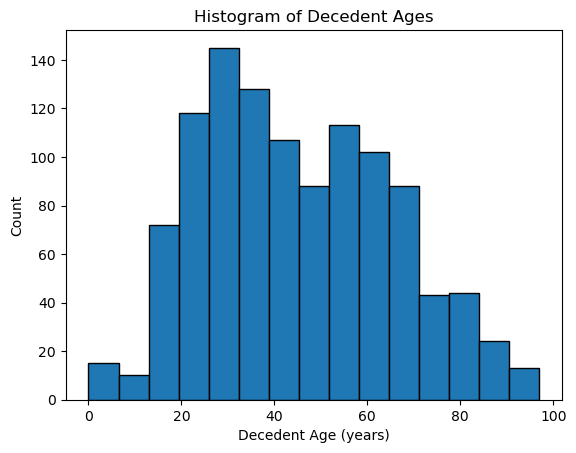

In [2]:
plt.hist(df['DecedentAge'], bins=15, edgecolor='black')
plt.title("Histogram of Decedent Ages")
plt.xlabel("Decedent Age (years)")
plt.ylabel("Count")
plt.show()

Here, we can see a peak at the late 20's to early 30's, with another small peak around the mid 50's. To make sure that this isn't biased based on population distribution, we also can compare this plot to the total population of Sacramento county by age group.

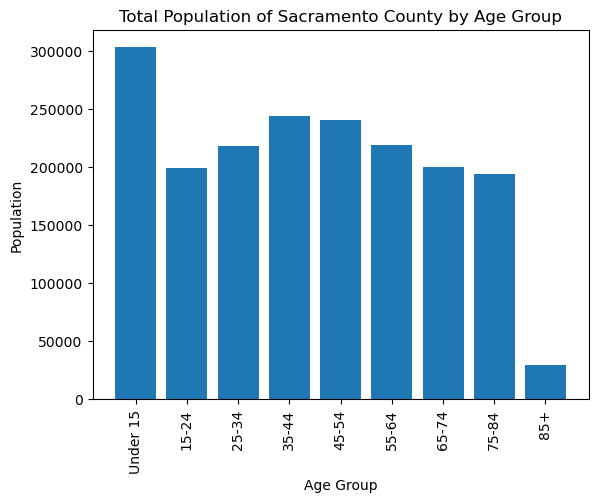

In [3]:
plt.bar(df_age_rebinned["Age Group"], df_age_rebinned["Population"])
plt.xlabel("Age Group")
plt.ylabel("Population")
plt.title("Total Population of Sacramento County by Age Group")
plt.xticks(rotation=90)
plt.show()

We see that there is a small, wide peak around 45 years of age. This gives us confidence that the peaks in the decedent age distribution are significant and not simply a product of there being more people of those ages. Now, let's look at age as a risk factor together with gender.

/var/folders/5r/11k9c_bd2tv2g7w5k65m3g980000gn/T/ipykernel_45352/4191319417.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_zip = df.pivot_table(index='Gender', columns='AgeGroup', values='DecedentAge', aggfunc='count').fillna(0)


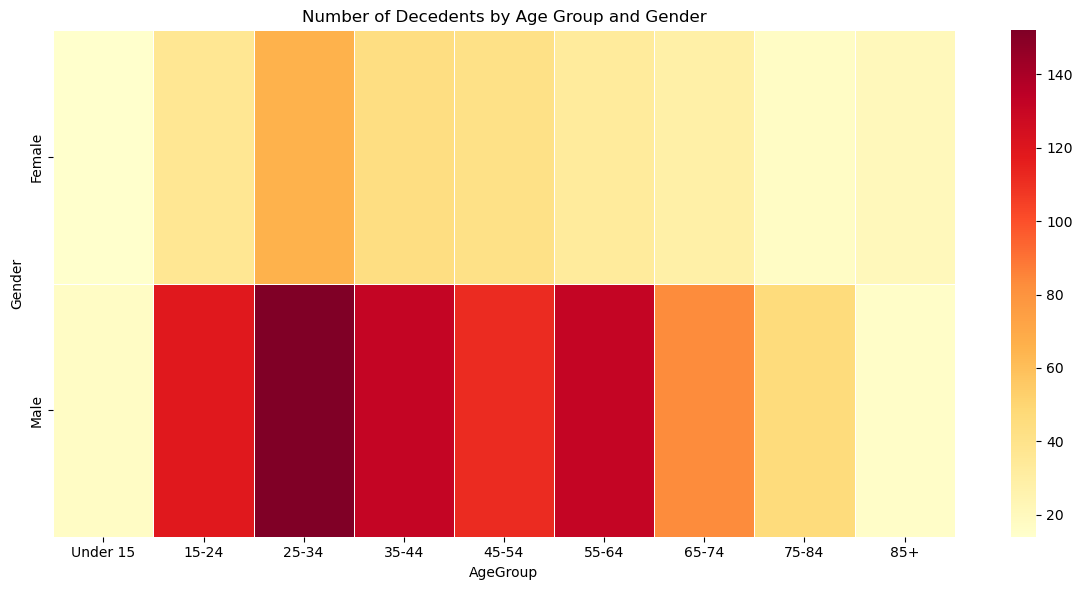

In [4]:
age_zip = df.pivot_table(index='Gender', columns='AgeGroup', values='DecedentAge', aggfunc='count').fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(age_zip, cmap="YlOrRd", linewidths=.5)
plt.title("Number of Decedents by Age Group and Gender")
plt.ylabel("Gender")
plt.xlabel("AgeGroup")
plt.tight_layout()
plt.show()

From this visualization, we can see that males are at much higher risk than females. The highest risk category is males 25-34 years old. The other three higher-risk categories are males aged 15-24, 35-44, and 55-64.

## Part 2: Time and location as risk factors

Are there some months, days of the week, or zip codes that are riskier than others? Let's find out.

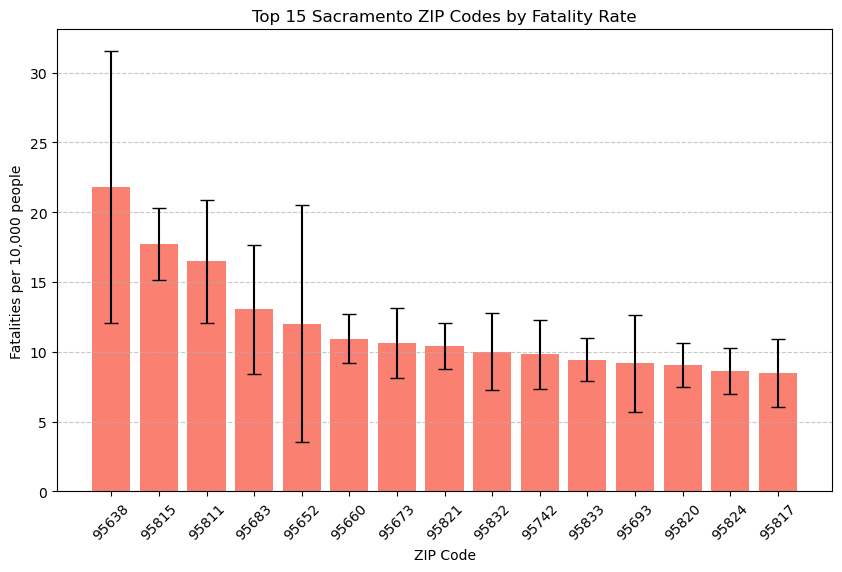

In [5]:
# Count incidents per zip and map it into the supplementary dataset
zip_counts = df['Incident_Zip'].value_counts()
zip_counts_dict = zip_counts.to_dict()
df_zip_pops['Deaths'] = df_zip_pops['Zip code'].map(zip_counts_dict)
df_zip_pops['fatality_rate_per_10000'] = df_zip_pops['Deaths'] / df_zip_pops['Population'].astype(int) * 10000

# Get top 15 zip codes by fatality rate
top_15_zips = df_zip_pops.sort_values(
    by='fatality_rate_per_10000',
    ascending=False
).head(15)

# Calculate standard error
top_15_zips['SE'] = np.sqrt((top_15_zips['fatality_rate_per_10000']/10000) * (1 - (top_15_zips['fatality_rate_per_10000']/10000)) / top_15_zips['Population'])*10000

# Bar plot
plt.figure(figsize=(10,6))
plt.bar(top_15_zips['Zip code'].astype(str), top_15_zips['fatality_rate_per_10000'], yerr=top_15_zips['SE'], capsize=5, color='salmon')

# Add labels and title
plt.xlabel('ZIP Code')
plt.ylabel('Fatalities per 10,000 people')
plt.title('Top 15 Sacramento ZIP Codes by Fatality Rate')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Show grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

One thing to notice about this plot are the large error bars for 95638 and 95652. This is due to the small population sizes of these zip codes. We are then less certain that these zip codes will consistently be in the top 15 in the future. However, we must keep in mind that fatality rates are not the whole picture. Fatality rates can exaggerate risk in commuter-heavy ZIPs or areas with very small populations. For this reason, to properly identify the highest-risk areas, we also need to look at the top 15 ZIPs by raw deaths.

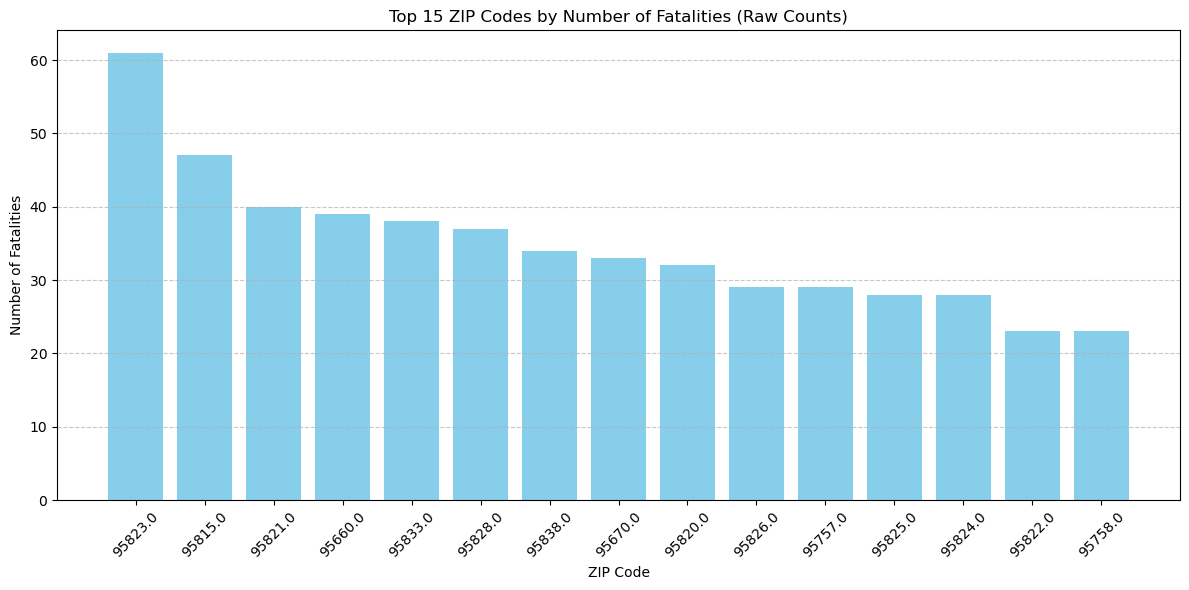

In [9]:
zip_counts = df['Incident_Zip'].value_counts().head(15)

plt.figure(figsize=(12,6))

plt.bar(
    zip_counts.index.astype(str),
    zip_counts.values,
    color='skyblue')

plt.xlabel('ZIP Code')
plt.ylabel('Number of Fatalities')
plt.title('Top 15 ZIP Codes by Number of Fatalities (Raw Counts)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The ZIPs that appear in both plots are 95815, 95821, 95660, 95833, 95820, and 95824. These are the highest-risk areas according to both raw counts and fatality rates.

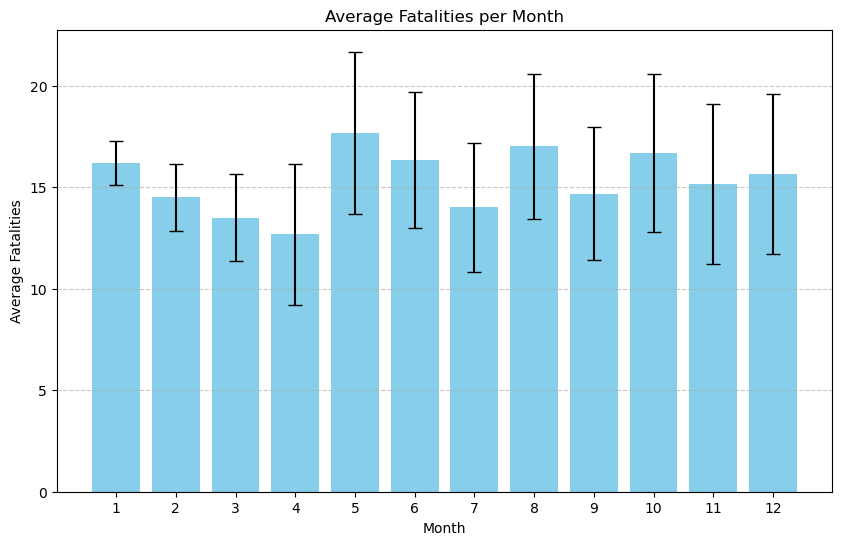

In [11]:
monthly_counts = df.groupby(['DeathYear', 'IncidentMonth']).size()
monthly_matrix = monthly_counts.unstack(fill_value=0)

means = monthly_matrix.mean(axis=0)
sems = monthly_matrix.sem(axis=0)

plt.figure(figsize=(10,6))

plt.bar(
    means.index,
    means.values,
    yerr=sems.values,
    capsize=5,
    color='skyblue'
)

plt.xlabel('Month')
plt.ylabel('Average Fatalities')
plt.title('Average Fatalities per Month')

plt.xticks(range(1,13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

We see the most average fatalities in May, August, and October. We see the least average fatalities in April, March, and July. The error bars plotted here are standard error of the mean. Fatalities seem almost cyclical in nature, with monthly peaks across different quarters of the year.

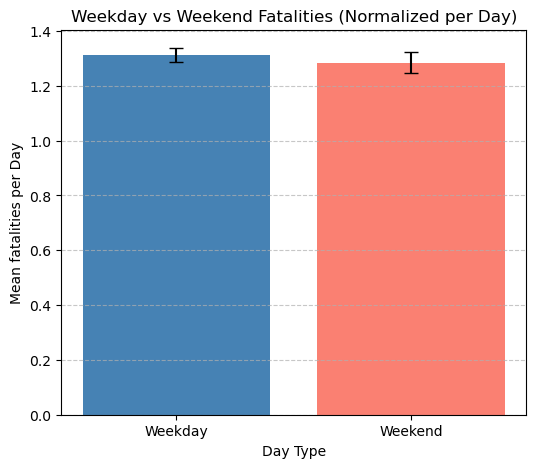

In [23]:
# fatalities per group
fatality_counts = df.groupby('Weekend').size()

# number of unique days per group
days_counts = df.groupby('Weekend')['DeathDate'].nunique()

rates = fatality_counts / days_counts

labels = ['Weekday', 'Weekend']
values = [
    rates.get(False, 0),
    rates.get(True, 0)
]

daily_counts = df.groupby(['Weekend', 'IncidentDate']).size().reset_index(name='count')

stats = daily_counts.groupby('Weekend')['count'].agg(['mean','sem'])

plt.figure(figsize=(6,5))

plt.bar(
    labels,
    stats['mean'],
    yerr=stats['sem'],
    capsize=5,
    color=['steelblue','salmon']
)

plt.xlabel('Day Type')
plt.ylabel('Mean fatalities per Day')
plt.title('Weekday vs Weekend Fatalities (Normalized per Day)')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This analysis takes into account that there are 5 days of the week and only 2 days of the weekend, computing fatality rates instead of raw counts. It seems that weekday and weekend fatalities occur at about the same rate, with weekend fatalities slightly higher. The error bars plotted here are standard error of the mean. We can see that these error bars are overlapping. Is the difference between weekday and weekend fatalities significant?

In [31]:
df['DeathDate'] = pd.to_datetime(df['DeathDate'])

daily_counts = (
    df.groupby('DeathDate')
      .size()
      .reset_index(name='Fatalities')
)

daily_counts['IncidentMonth'] = daily_counts['DeathDate'].dt.month
daily_counts['Weekend'] = daily_counts['DeathDate'].dt.weekday >= 5

weekday_data = daily_counts[daily_counts['Weekend'] == False]['Fatalities']
weekend_data = daily_counts[daily_counts['Weekend'] == True]['Fatalities']

stat, p_value = mannwhitneyu(weekday_data, weekend_data, alternative='two-sided')

print(f"U statistic: {stat}")
print(f"p-value: {p_value}")

U statistic: 64225.0
p-value: 0.541686597550574


This difference is certainly not statistically significant. Weekday and weekend fatalities are approximately the same. Is there, however, a difference in certain months?

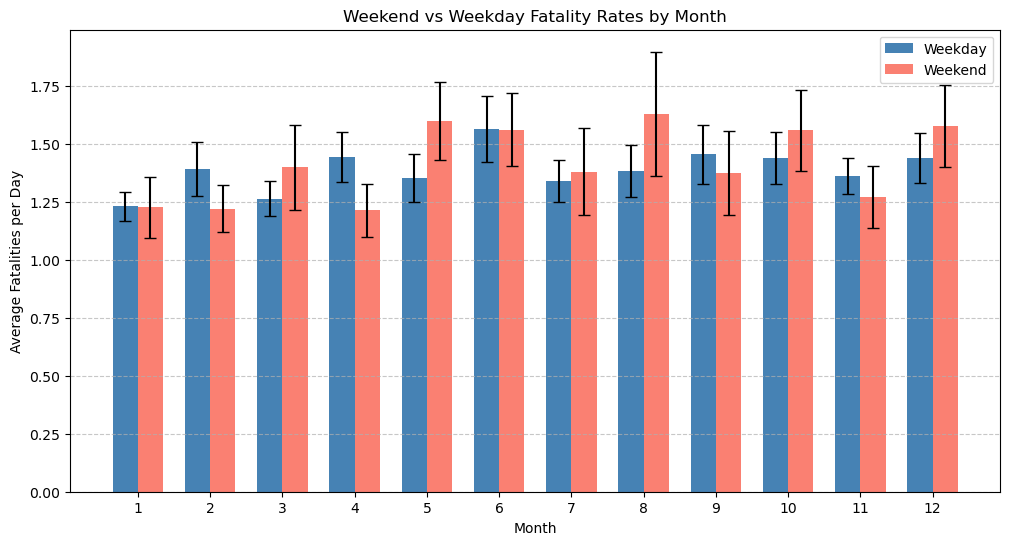

In [34]:
monthly_rates = (
    daily_counts
    .groupby(['IncidentMonth', 'Weekend'])['Fatalities']
    .mean()
    .unstack(fill_value=0)
)

months = monthly_rates.index
x = np.arange(len(months))
width = 0.35

monthly_stats = (
    daily_counts
    .groupby(['IncidentMonth', 'Weekend'])['Fatalities']
    .agg(['mean','sem'])
    .unstack()
)

weekday_means = monthly_stats['mean'][False]
weekend_means = monthly_stats['mean'][True]

weekday_std = monthly_stats['sem'][False]
weekend_std = monthly_stats['sem'][True]

plt.figure(figsize=(12,6))

plt.bar(x - width/2, weekday_means, width,
        yerr=weekday_std, capsize=4, label='Weekday', color='steelblue')

plt.bar(x + width/2, weekend_means, width,
        yerr=weekend_std, capsize=4, label='Weekend', color='salmon')

plt.xlabel('Month')
plt.ylabel('Average Fatalities per Day')
plt.title('Weekend vs Weekday Fatality Rates by Month')

plt.xticks(x, months)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

It seems as though the weekend to weekday fatality rate differs across months. For example, in February and April, weekday fatality rates are higher. In May and August, weekend fatality rates are higher. Interestingly, the months with the highest average fatalities have a higher weekend fatality rate than weekday fatality rate. However, the standard error of the mean bars are overlappling in many months, so this difference may not be statistically significant.

## Part 3: Number of decedents over time

The last plot of this project will be a simple one: plotting the number of decedents over time.

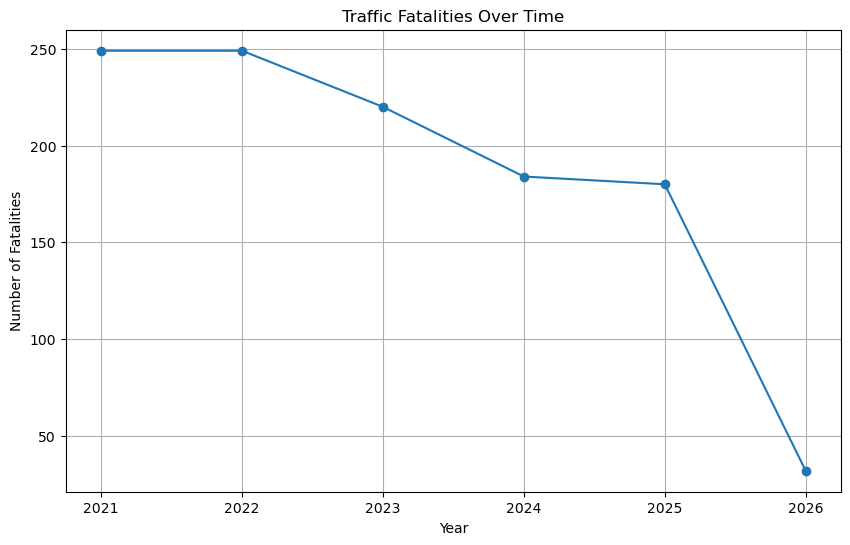

In [35]:
year_counts = df['DeathYear'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.title("Traffic Fatalities Over Time")
plt.grid(True)
plt.show()

From 2021 to 2025, it seems as though traffic fatalities are decreasing. We do not have enough data about 2026 to draw any conclusions yet for this year.